In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from helper_functions.helper_functions import *
from data.data_operators import BScanDepthDataset,ComposeBScanTransforms
from networks.Unets import BnetSmallKernelSmarterRefine,BnetMean
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
device = 'cuda'
pin_memory = True
step = 480
THICKNESS_MM = 3.5  # sample thickness

model_path = '/home/kjaworski/Pulpit/Themporal_thermal_imaging_code/Temporal_thermal_image/models_logs_official/smart_net_heating_and_cooling/best_model_clean.pth'

# Mode of the experimentation
data = '/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/topology_exp/topology_exp_bscans'
depth = '/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/topology_exp/topology_exp_masks'

sigma_list = [0.065] 
noise_augmentation=ComposeBScanTransforms([NoiseAdditionExperiment(sigma=sigma_list[-1])])

model=BnetSmallKernelSmarterRefine().to(device)
# model=BnetMean().to(device)
state_dict=torch.load(model_path)
model.load_state_dict(state_dict)
model.eval()

# validation (robustness metric only)
test_dataset = BScanDepthDataset(
    bscan_dir=data,
    depth_dir=depth,
    transform=noise_augmentation,
    normalization_path="/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/normalization_params.npz",
    derivative_mode=None,
    log_scaling=True,
    cooling_phase=False
)

# -------------------------
# Loaders
# -------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=24,
    pin_memory=pin_memory
)

In [3]:
model.eval()

pred_all = []
mask_all = []


with torch.no_grad():
    for X, mask in tqdm(test_loader):

        X = X.to(device)
        mask = mask.to(device)

        pred = model(X)


        pred_all.append(pred.cpu())
        mask_all.append(mask.cpu())

pred_all = torch.cat(pred_all, dim=0)
mask_all = torch.cat(mask_all, dim=0)

100%|██████████| 30/30 [00:05<00:00,  5.72it/s]


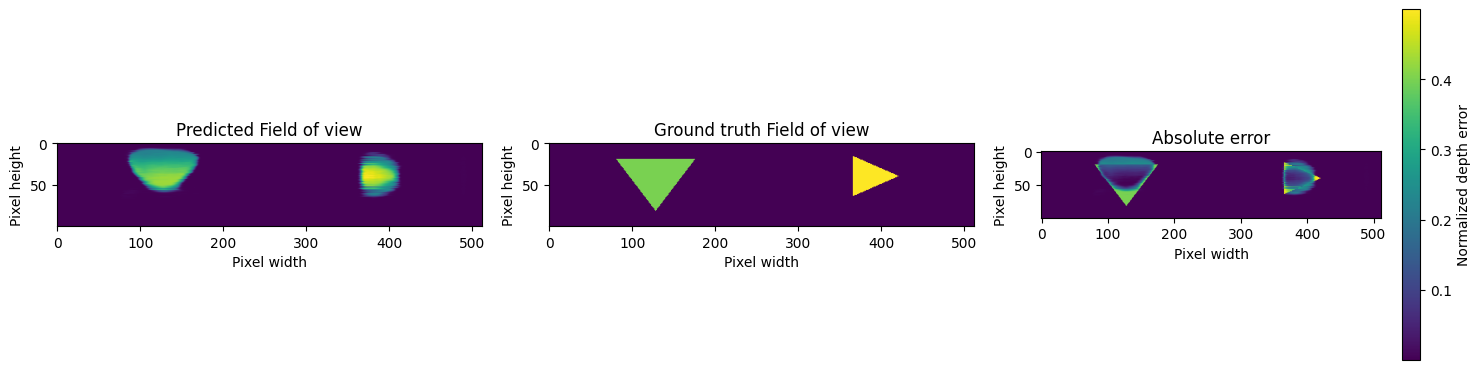

In [4]:
visualize_global_prediction(pred_all[200:300,:],mask_all[200:300,:],n=1)

Triangle mean: 0.20022019743919373 | Triangle median: 0.2315545380115509 | Triangle max: 0.4002874493598938 | Triangle min: 9.663126547820866e-05


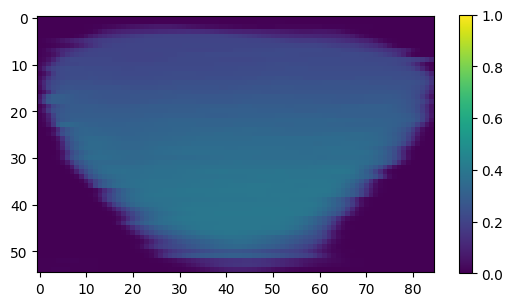

In [5]:
left=pred_all[205:260,85:170]
plt.imshow(left,vmin=0,vmax=1)
plt.colorbar(shrink=0.7)
print(f'Triangle mean: {torch.mean(left)} | Triangle median: {torch.median(left)} | Triangle max: {torch.max(left)} | Triangle min: {torch.min(left)}')

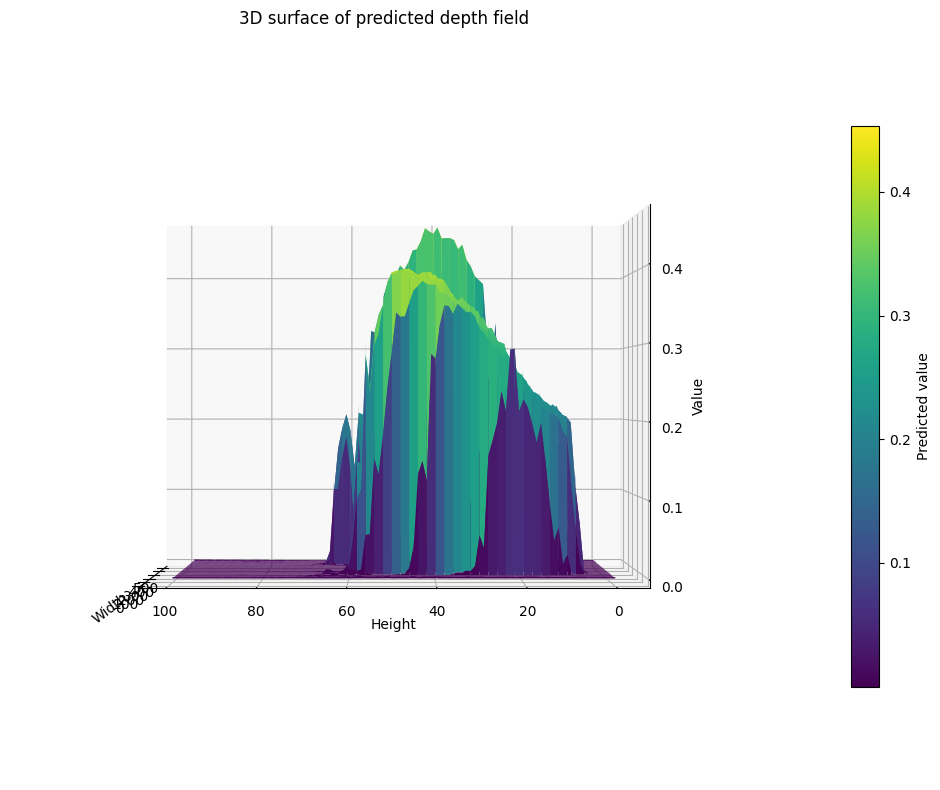

In [13]:
tomografic_reconstruction(pred_all[200:300,:],elev=0,azim=180)